# Notebook B - Preference Cost

What does each preference mechanism cost in service quality, and what does it
return in driver welfare? All metrics are deltas against the Exp 1 baseline
(nearest, no preferences), matched per (d, R, behaviour, initial_conditions).

Summary data only. Run separately for each geometry.

In [1]:
from pathlib import Path

GEOMETRY = 'balanced'          # 'balanced' or 'imbalanced'
BASELINE = 'exp1'              # reference: nearest, no preferences
TREATMENTS = ['exp2', 'exp3', 'exp4', 'exp5', 'exp6', 'exp7']

CACHE_DIR = Path('.') / 'cache'
FORCE_RECOMPUTE = False

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from exp_utils import load_experiment_set, match_run_pairs, fmt_display, exp_label, apply_pub_style, legend_outside

apply_pub_style()

## 1. Load baseline and treatment experiments

In [ ]:
df = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR,
                         experiments=[BASELINE] + TREATMENTS,
                         force=FORCE_RECOMPUTE)
if df.empty:
    raise RuntimeError(f'No data for geometry={GEOMETRY!r}. Run cache_all.py first.')

EXP_ALGO = df.drop_duplicates('experiment').set_index('experiment')['algorithm'].to_dict()
TLABEL = {e: exp_label(e, EXP_ALGO.get(e)) for e in TREATMENTS}
present_treatments = [e for e in TREATMENTS if e in df['experiment'].unique()]
_cmap = plt.get_cmap('tab10')
TCOLOR = {e: _cmap(i % 10) for i, e in enumerate(present_treatments)}

R_vals = sorted(df['R'].dropna().unique())
d_vals = sorted(df['d'].dropna().unique())
KEYS = ['d', 'R', 'behaviour', 'initial_conditions']

print(f'Geometry  : {GEOMETRY}')
print(f'Baseline  : {BASELINE} ({EXP_ALGO.get(BASELINE)})')
print(f'Treatments: {[TLABEL[e] for e in present_treatments]}')
print(f'R values  : {R_vals}')

In [4]:
# Delta metrics: positive value = treatment is higher than baseline.
DELTA_METRICS = [
    ('service_rate',            'Service rate',          '{:+.3f}'),
    ('wait_to_pickup_mean',     'Wait to pickup (TU)',   '{:+.0f}'),
    ('final_safety_mean',       'Driver safety',         '{:+.2f}'),
    ('final_satisfaction_mean', 'Satisfaction',          '{:+.2f}'),
    ('final_income_mean',       'Income',                '{:+.1f}'),
    ('income_gini',             'Income Gini',           '{:+.3f}'),
]
DELTA_METRICS = [(c, l, f) for c, l, f in DELTA_METRICS if c in df.columns]
DELTA_COLS = [c for c, _, _ in DELTA_METRICS]

base_df = df[df['experiment'] == BASELINE]


def treatment_deltas(treat):
    '''Return per-run deltas (treat - baseline) matched on KEYS.'''
    t_df = df[df['experiment'] == treat]
    m = match_run_pairs(base_df, t_df, keys=KEYS)
    out = m[KEYS].copy()
    for col in DELTA_COLS:
        a, b = f'{col}_exp1', f'{col}_exp2'
        if a in m.columns and b in m.columns:
            out[col] = m[b] - m[a]
    out['experiment'] = treat
    return out


deltas = {e: treatment_deltas(e) for e in present_treatments}
print('matched pairs per treatment:', {e: len(v) for e, v in deltas.items()})

matched pairs per treatment: {'exp2': 60, 'exp3': 60, 'exp4': 60, 'exp5': 60, 'exp6': 60, 'exp7': 60}


## 2. Delta summary table

Mean delta against baseline across all (d, R, behaviour, ic) for each treatment.

In [5]:
rows = []
for e in present_treatments:
    r = deltas[e][DELTA_COLS].mean()
    r['treatment'] = TLABEL[e]
    rows.append(r)
tbl = pd.DataFrame(rows).set_index('treatment')[DELTA_COLS]
display(fmt_display(tbl.reset_index(), fmt={c: f for c, _, f in DELTA_METRICS}))

,treatment,service_rate,wait_to_pickup_mean,final_safety_mean,final_satisfaction_mean,final_income_mean,income_gini
0,exp2: nearest_region_pref,+0.001,-0,-0.05,-0.24,-41.3,+0.006
1,exp3: nearest_distance_pref,+0.002,+0,-0.04,+7.87,-164.0,+0.015
2,exp4: nearest_passenger_pref,-0.003,-0,-0.01,-0.53,+2.5,+0.014
3,exp5: nearest_two_sided_region_pass_pref,-0.007,-1,+0.18,-0.96,-98.3,+0.008
4,exp6: safety_objective_two_sided,-0.011,-1,+0.01,-1.62,-240.8,+0.029
5,exp7: safety_objective,-0.008,-1,-0.43,-1.04,-246.6,+0.036


## 3. Delta vs R, one panel per metric

All treatments in a 2x3 grid. Each point averages the per-run delta over
d / behaviour / ic; error bars show the standard deviation across d. Shows at
which demand levels each preference mechanism hurts or helps most.

In [ ]:
ncols = 3
nrows = int(np.ceil(len(DELTA_METRICS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).reshape(-1)
handles = labels = None
for ax, (col, label, _f) in zip(axes, DELTA_METRICS):
    for e in present_treatments:
        d = deltas[e]
        per_d = d.groupby(['R', 'd'])[col].mean().reset_index()
        gmean = per_d.groupby('R')[col].mean().reindex(R_vals)
        gstd = per_d.groupby('R')[col].std().reindex(R_vals)
        ax.errorbar(R_vals, gmean.values, yerr=gstd.values, fmt='o-',
                    color=TCOLOR[e], label=TLABEL[e], capsize=3,
                    linewidth=1.6, markersize=5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Demand ratio R')
    ax.set_ylabel(f'delta {label}')
    ax.set_title(label)
    ax.set_xticks(R_vals)
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
for ax in axes[len(DELTA_METRICS):]:
    ax.axis('off')
fig.legend(handles, labels, loc='lower center', ncol=3,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

## 4. Preference tax heatmap

Delta service rate vs baseline across (d, R), one panel per treatment. Red =
service lost relative to nearest. Identifies the operating regimes where
preferences become costly.

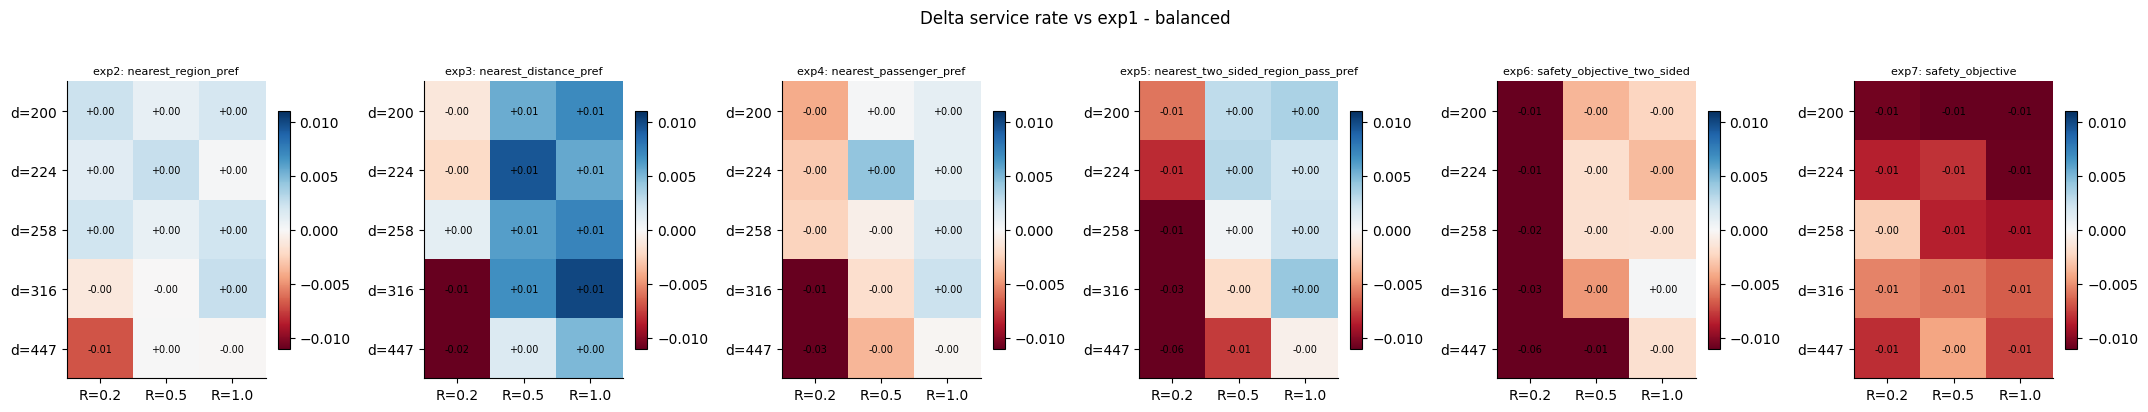

In [7]:
col = 'service_rate'
vmax = max(abs(deltas[e][col].mean()) for e in present_treatments) if present_treatments else 0.1
vmax = max(vmax, 0.01)
fig, axes = plt.subplots(1, len(present_treatments),
                         figsize=(3.6 * len(present_treatments), 4))
axes = np.atleast_1d(axes)
for ax, e in zip(axes, present_treatments):
    piv = deltas[e].pivot_table(index='d', columns='R', values=col, aggfunc='mean')
    piv = piv.reindex(index=sorted(piv.index), columns=R_vals)
    im = ax.imshow(piv.values, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'R={c}' for c in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f'd={int(v)}' for v in piv.index])
    ax.set_title(TLABEL[e], fontsize=12)
    ax.grid(False)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(f'Delta service rate vs {BASELINE} - {GEOMETRY}', y=1.02)
plt.tight_layout()
plt.show()

## 5. What drivers gain

Delta satisfaction and delta income Gini against baseline, vs R. Place these
beside the service-rate cost from Section 4 to read the trade-off directly:
a treatment is worthwhile only if a positive driver gain offsets the service tax.

In [ ]:
gain_metrics = [m for m in [('final_satisfaction_mean', 'delta satisfaction'),
                            ('income_gini', 'delta income Gini'),
                            ('final_safety_mean', 'delta driver safety')]
                if m[0] in df.columns]
fig, axes = plt.subplots(1, len(gain_metrics), figsize=(3.4 * len(gain_metrics), 3.5))
axes = np.atleast_1d(axes)
for ax, (col, label) in zip(axes, gain_metrics):
    for e in present_treatments:
        g = deltas[e].groupby('R')[col].mean().reindex(R_vals)
        ax.plot(R_vals, g.values, 'o-', color=TCOLOR[e], label=TLABEL[e],
                linewidth=1.6, markersize=4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Demand ratio R')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(R_vals)
fig.suptitle(f'Driver welfare delta vs {BASELINE} - {GEOMETRY}', y=1.03)
fig.tight_layout()
legend_outside(fig, ax=axes[0])
plt.show()

## 6. Declines per driver

Average declines per driver generated by each treatment (the baseline nearest
algorithm makes none). Shows how many declines each preference type introduces
and whether it scales with demand.

In [ ]:
if 'avg_total_declines' in df.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(present_treatments))
    w = 0.8 / max(len(R_vals), 1)
    for i, r in enumerate(R_vals):
        vals = [df[(df['experiment'] == e) & (df['R'] == r)]['avg_total_declines'].mean()
                for e in present_treatments]
        ax.bar(x + i * w, vals, w, label=f'R={r}')
    ax.set_xticks(x + w * (len(R_vals) - 1) / 2)
    ax.set_xticklabels([TLABEL[e] for e in present_treatments], rotation=20,
                       ha='right', fontsize=12)
    ax.set_ylabel('avg total declines per driver')
    ax.set_title(f'Declines per driver by treatment and R - {GEOMETRY}')
    ax.legend(title='R')
    plt.tight_layout()
    plt.show()
else:
    print('avg_total_declines not available in summary data')

## Significance

Two complementary tests (see `guides/STATISTICAL_ANALYSIS_PLAN.md`):

- **Sweep** - paired Wilcoxon signed-rank across the x1 sweep, points paired by
  d / R / behaviour / ic. The headline test. `sweep_cliff` is Cliff's delta,
  `sweep_signs` the sign-agreement count, `sweep_p_adj` the Holm-corrected p.
- **Focus** - replicate test at the focus operating point
  (d=258, R=0.5, go_back, ic=home; K=11 runs per algorithm). `foc_diff` and its
  95% CI are the Welch mean difference; `foc_cohens_d` / `foc_cliff` are the
  effect sizes; `foc_welch_p` / `foc_mw_p` the Welch and Mann-Whitney p-values.

Positive deltas mean the first algorithm scores higher. P-values are Holm-corrected
within each metric across the comparisons. Inequality (Gini) is never t-tested: its
focus p-value is Mann-Whitney and the headline inequality claim uses a bootstrap CI
(below). Trajectories are compared in `safety_evolution.ipynb`, not by per-timestamp
tests (successive batches are autocorrelated).

In [10]:
from exp_utils import significance_summary, FOCUS_SETUP

df_reps = load_experiment_set(GEOMETRY, cache_dir=CACHE_DIR,
                              experiments=[BASELINE] + TREATMENTS,
                              include_reps=True, force=FORCE_RECOMPUTE)

COMPARISONS = [(e, BASELINE) for e in present_treatments]
sig = significance_summary(df, df_reps, COMPARISONS, DELTA_COLS, setup=FOCUS_SETUP)
SIG_SHOW = ['comparison', 'metric', 'sweep_n', 'sweep_p_adj', 'sweep_cliff', 'sweep_mag',
            'sweep_signs', 'foc_diff', 'foc_ci_lo', 'foc_ci_hi', 'foc_welch_p',
            'foc_mw_p', 'foc_p_adj', 'foc_cohens_d']
SIG_FMT = {'sweep_p_adj': '{:.2g}', 'sweep_cliff': '{:+.2f}', 'foc_diff': '{:+.3f}',
           'foc_ci_lo': '{:+.3f}', 'foc_ci_hi': '{:+.3f}', 'foc_welch_p': '{:.2g}',
           'foc_mw_p': '{:.2g}', 'foc_p_adj': '{:.2g}', 'foc_cohens_d': '{:+.2f}'}
SIG_SHOW = [c for c in SIG_SHOW if c in sig.columns]
display(fmt_display(sig[SIG_SHOW], fmt=SIG_FMT))

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,metric,sweep_n,sweep_p_adj,sweep_cliff,sweep_mag,sweep_signs,foc_diff,foc_ci_lo,foc_ci_hi,foc_welch_p,foc_mw_p,foc_p_adj,foc_cohens_d
0,exp2 vs exp1,service_rate,60,0.13,+0.07,negligible,39/60 a>b,+0.002,+0.001,+0.004,0.011,0.01,0.032,+1.21
1,exp2 vs exp1,wait_to_pickup_mean,60,0.58,-0.02,negligible,30/60 a<b,-0.005,-0.243,+0.234,0.97,0.79,0.97,-0.02
2,exp2 vs exp1,final_safety_mean,60,1,-0.02,negligible,31/60 a<b,-0.054,-0.333,+0.226,0.69,0.79,1,-0.17
3,exp2 vs exp1,final_satisfaction_mean,60,0.0024,-0.07,negligible,39/60 a<b,+0.089,-0.127,+0.305,0.4,0.51,0.8,+0.37
4,exp2 vs exp1,final_income_mean,60,3.5e-06,-0.07,negligible,46/60 a<b,-22.247,-53.856,+9.363,0.16,0.17,0.31,-0.63
5,exp2 vs exp1,income_gini,60,5.1e-05,+0.09,negligible,45/60 a>b,-0.000,-0.002,+0.001,-,1,1,-
6,exp3 vs exp1,service_rate,60,0.016,+0.16,small,43/60 a>b,+0.008,+0.006,+0.010,1.1e-08,8.2e-05,6.6e-08,+4.20
7,exp3 vs exp1,wait_to_pickup_mean,60,0.58,+0.02,negligible,37/60 a>b,+0.079,-0.119,+0.277,0.41,0.32,0.82,+0.36
8,exp3 vs exp1,final_safety_mean,60,1,-0.04,negligible,33/60 a<b,-0.202,-0.444,+0.040,0.097,0.17,0.29,-0.74
9,exp3 vs exp1,final_satisfaction_mean,60,9.8e-11,+0.56,large,60/60 a>b,+7.527,+7.392,+7.663,3.4e-18,8.2e-05,2e-17,+52.19


In [11]:
# Headline inequality claim: bootstrap CI of the income-Gini difference at the
# focus setup, on the taxi-level income vectors pooled across replicates.
from exp_utils import pooled_focus_taxi_values, bootstrap_gini_diff_ci

base_income = pooled_focus_taxi_values(GEOMETRY, BASELINE, 'trip_income')
rows = []
for e in present_treatments:
    tv = pooled_focus_taxi_values(GEOMETRY, e, 'trip_income')
    r = bootstrap_gini_diff_ci(tv, base_income, n_boot=1000, seed=0)
    rows.append({'comparison': f'{e} vs {BASELINE}', 'gini': r['gini_a'],
                 'baseline_gini': r['gini_b'], 'gini_diff': r['diff'],
                 'ci_lo': r['lo'], 'ci_hi': r['hi'], 'ci_excludes_0': r['significant']})
display(fmt_display(pd.DataFrame(rows),
    fmt={'gini': '{:.3f}', 'baseline_gini': '{:.3f}', 'gini_diff': '{:+.3f}',
         'ci_lo': '{:+.3f}', 'ci_hi': '{:+.3f}'}))

[cache HIT]  exp1_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp2_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp3_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp4_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp5_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp6_balanced_summary.pkl  ->  loading summary
[cache HIT]  exp7_balanced_summary.pkl  ->  loading summary


,comparison,gini,baseline_gini,gini_diff,ci_lo,ci_hi,ci_excludes_0
0,exp2 vs exp1,0.082,0.082,-0.000,-0.001,+0.001,False
1,exp3 vs exp1,0.090,0.082,+0.008,+0.007,+0.010,True
2,exp4 vs exp1,0.086,0.082,+0.004,+0.003,+0.005,True
3,exp5 vs exp1,0.085,0.082,+0.003,+0.002,+0.004,True
4,exp6 vs exp1,0.090,0.082,+0.008,+0.007,+0.010,True
5,exp7 vs exp1,0.094,0.082,+0.012,+0.011,+0.013,True
